In [3]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

In [4]:
# Caminho do arquivo CSV
try:
    RAIZ = Path().resolve().parent.parent
    CAMINHO = Path(RAIZ, "arquivos/exemplo1_ouro.csv")
except NameError:
    raise NameError(
        "Não foi possível determinar o caminho do arquivo. Certifique-se de que o script está sendo executado em um ambiente adequado."
    )

In [5]:
# Dataframe e estimativas
df = pd.read_csv(CAMINHO)

medicoes = df["medicao_g"].to_numpy()
n_vals = df["n"].to_numpy()

# Filtro alpha recursivo
x = 1000.0
estimativas = []
for i, med in enumerate(medicoes, start=1):
    alpha = 1 / i
    x += alpha * (med - x)
    estimativas.append(x)

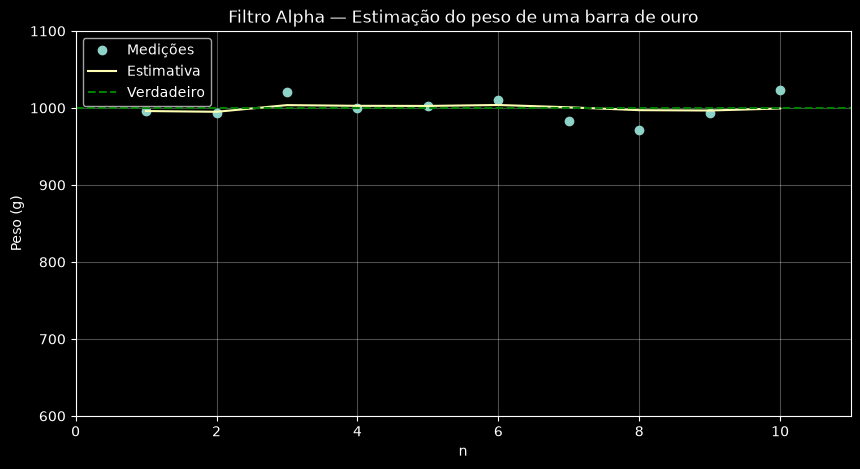

In [6]:
# Gráfico
plt.figure(figsize=(10, 5))
plt.plot(n_vals, medicoes, "o", label="Medições")
plt.plot(n_vals, estimativas, "-", label="Estimativa")
plt.axhline(1000, ls="--", color="g", label="Verdadeiro")
plt.xlabel("n")
plt.ylabel("Peso (g)")
plt.axis((0.0, 11.0, 600.0, 1100.0))
plt.legend()
plt.grid(True, alpha=0.3)
plt.title("Filtro Alpha \u2014 Estimação do peso de uma barra de ouro")
plt.show()

## Descrição

Este notebook implementa um **filtro alpha** (caso particular do filtro de Kalman)
para estimar o peso real de uma barra de ouro a partir de 10 medições ruidosas.

### Algoritmo

O filtro alpha é definido por:

$$
\hat{x}_{n} = \hat{x}_{n-1} + \alpha_n \cdot (z_n - \hat{x}_{n-1})
$$

onde:
- $\hat{x}_{n}$ é a estimativa no instante $n$
- $z_n$ é a medição no instante $n$
- $\alpha_n = \frac{1}{n}$ é o ganho, que diminui com o tempo

O ganho decrescente faz com que as primeiras medições tenham maior impacto na
estimativa, enquanto as últimas contribuem menos — o filtro "confia" mais em
sua própria estimativa conforme mais dados são processados.

### Resultados

O gráfico gerado mostra:
- **Pontos azuis**: medições individuais (ruidosas)
- **Linha laranja**: estimativa fornecida pelo filtro alpha
- **Linha tracejada verde**: valor verdadeiro (1000 g)

Observa-se que a estimativa converge para próximo do valor real mesmo com
flutuações significativas nas medições.